In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('AmesHousing.csv')

In [4]:
df.sample(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2724,2725,905201090,20,RL,NaN,14175,Pave,NaN,Reg,Bnk,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,168000
619,620,534476320,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,128900
981,982,923252075,80,RL,62.0,7706,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,Shed,700,8,2009,WD,Normal,131250
694,695,902103120,90,RM,57.0,10307,Pave,Grvl,Reg,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,103500
494,495,528315090,60,RL,82.0,9430,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,337000


In [7]:
missingperc=df.isnull().mean()*100
cols_to_drop=missingperc[missingperc[missingperc>70].index]
cols_to_drop.index

Index(['Alley', 'Pool QC', 'Fence', 'Misc Feature'], dtype='object')

In [8]:
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [9]:
df.duplicated().sum()

0

In [10]:
df.info()
df.drop(columns=['Order','PID'],inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [11]:
filter=df.corr(numeric_only=True)['SalePrice']

In [12]:
filter[(filter>0.5)|(filter <-0.5)]

Overall Qual      0.799262
Year Built        0.558426
Year Remod/Add    0.532974
Mas Vnr Area      0.508285
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Gr Liv Area       0.706780
Full Bath         0.545604
Garage Yr Blt     0.526965
Garage Cars       0.647877
Garage Area       0.640401
SalePrice         1.000000
Name: SalePrice, dtype: float64

EDA ON NUMERICAL COLUMNS


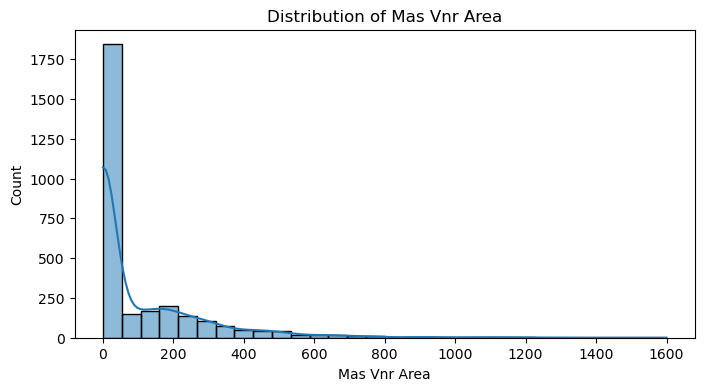

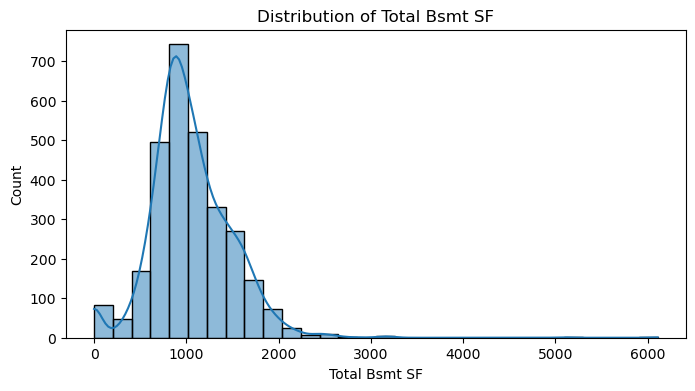

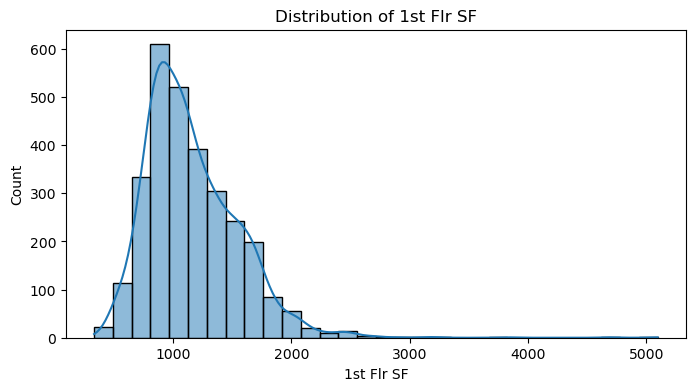

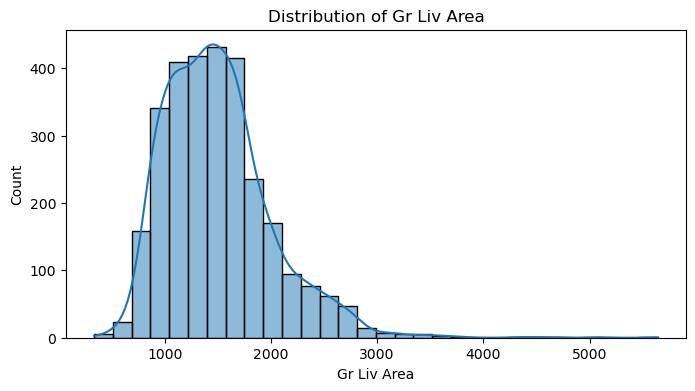

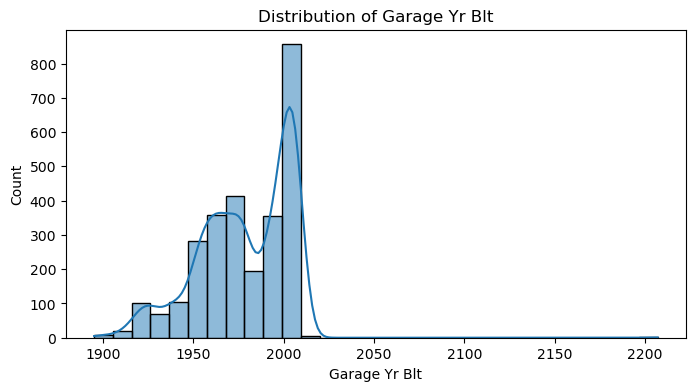

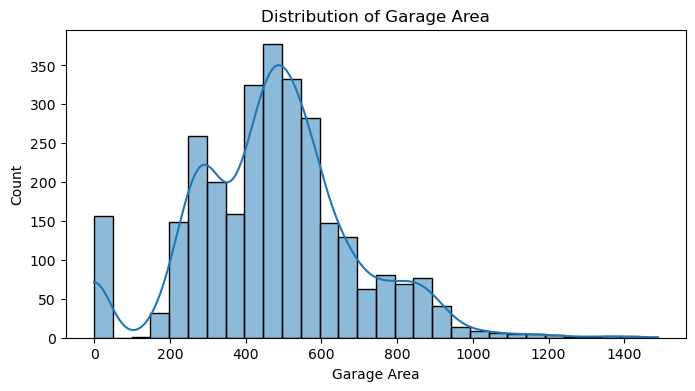

In [13]:
features = [
    'Mas Vnr Area',
    'Total Bsmt SF',
    '1st Flr SF',
    'Gr Liv Area',
    'Garage Yr Blt',
    'Garage Area'
]

for feature in features:
    plt.figure(figsize=(8,4))
    sns.histplot(data=df, x=feature, kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.show()

<Axes: xlabel='Garage Cars', ylabel='count'>

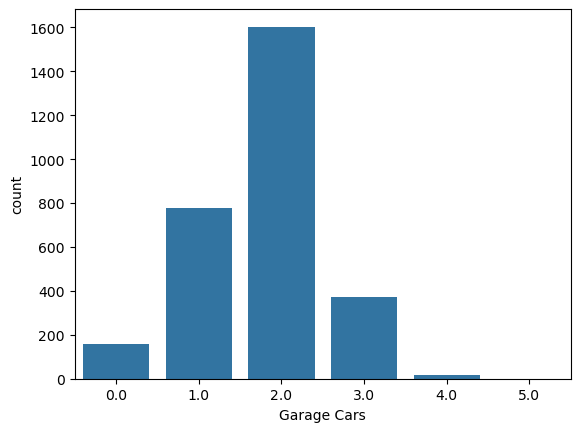

In [14]:
sns.countplot(x='Garage Cars',data=df)

<Axes: xlabel='Full Bath', ylabel='count'>

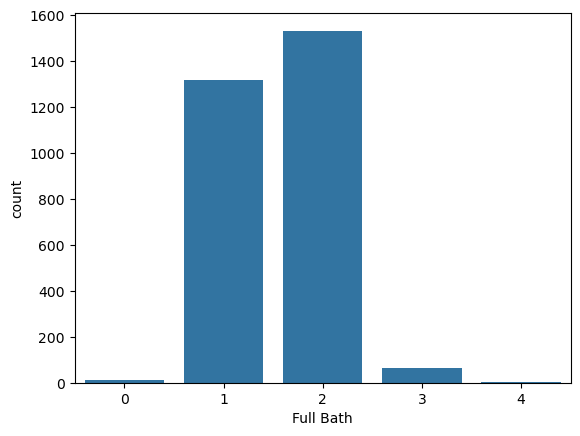

In [15]:
sns.countplot(x='Full Bath',data=df)

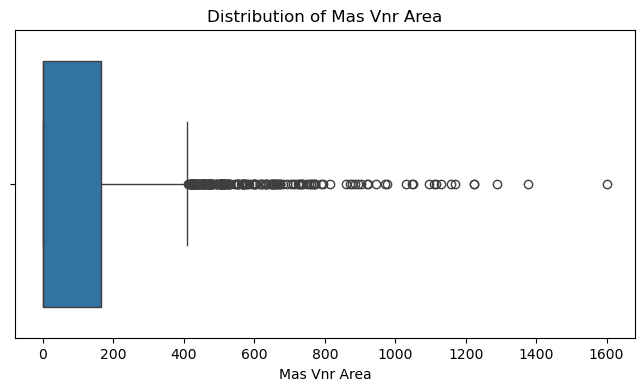

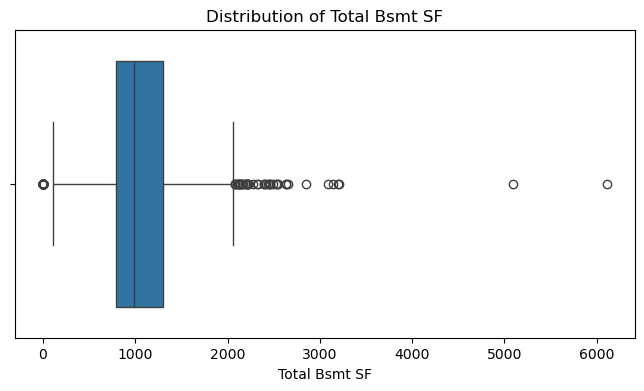

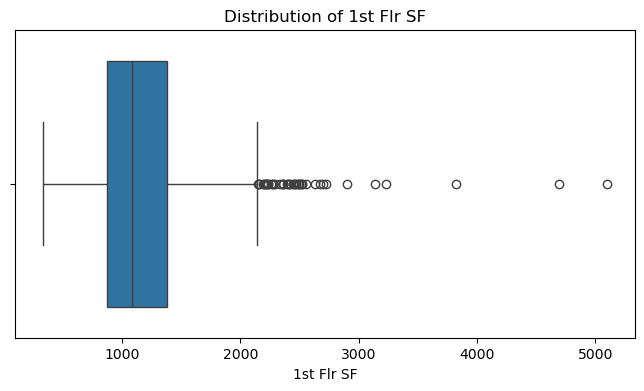

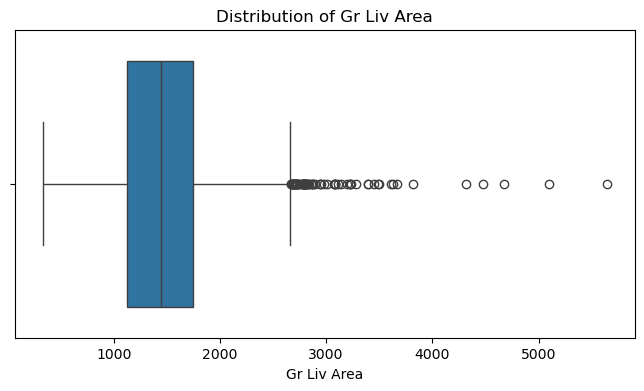

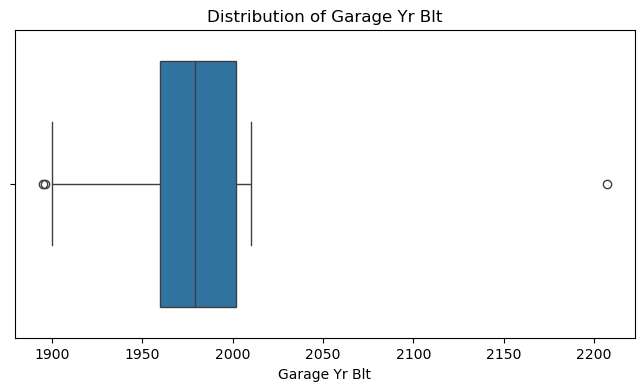

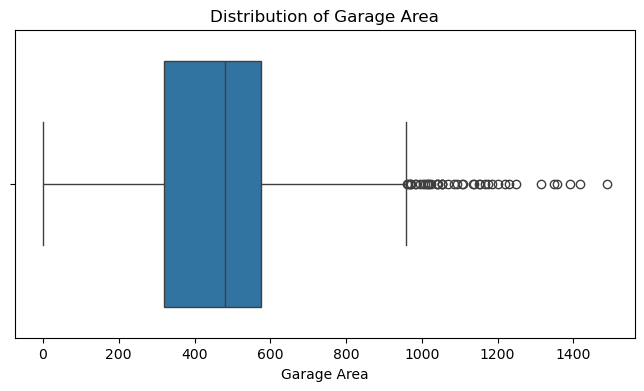

In [16]:
features = [
    'Mas Vnr Area',
    'Total Bsmt SF',
    '1st Flr SF',
    'Gr Liv Area',
    'Garage Yr Blt',
    'Garage Area'
]

for feature in features:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=feature)
    plt.title(f'Distribution of {feature}')
    plt.show()

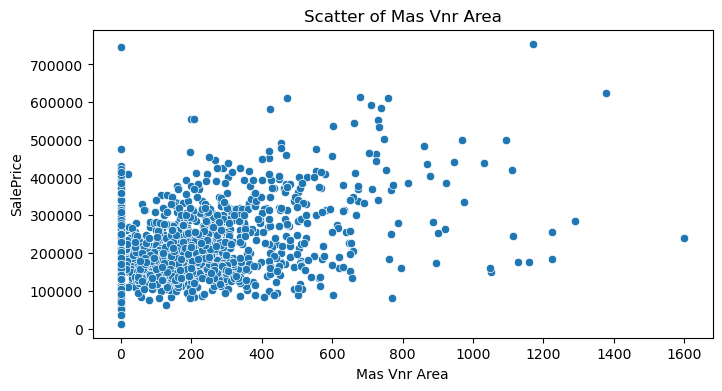

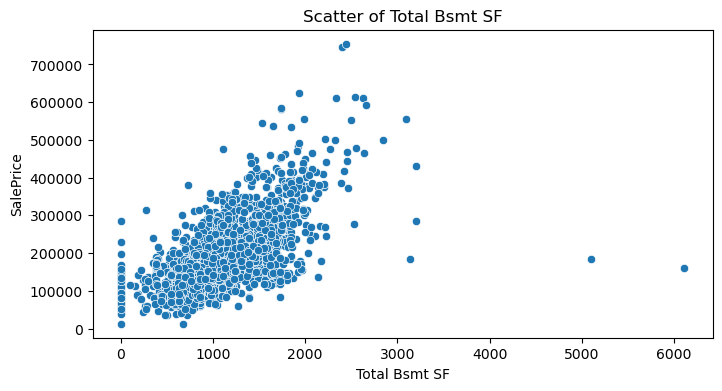

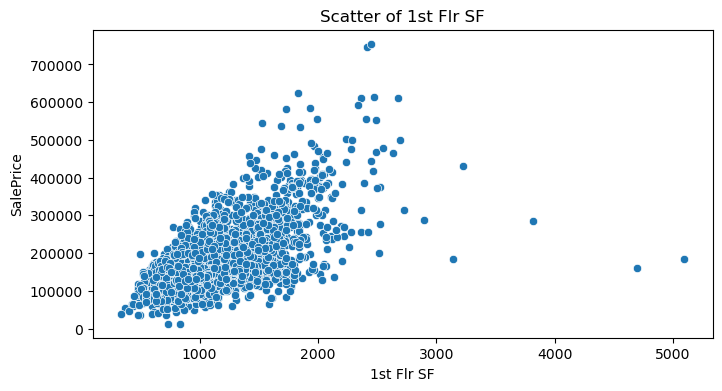

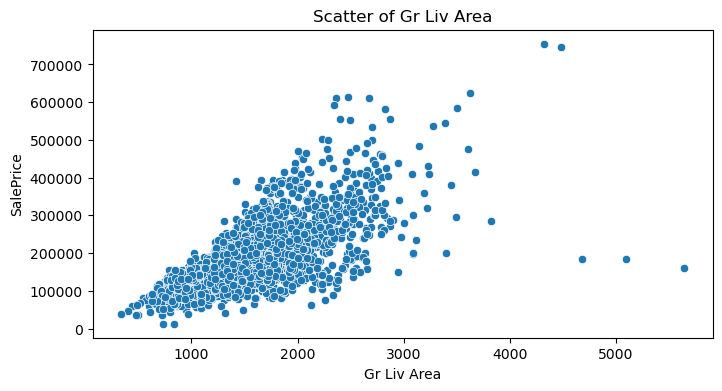

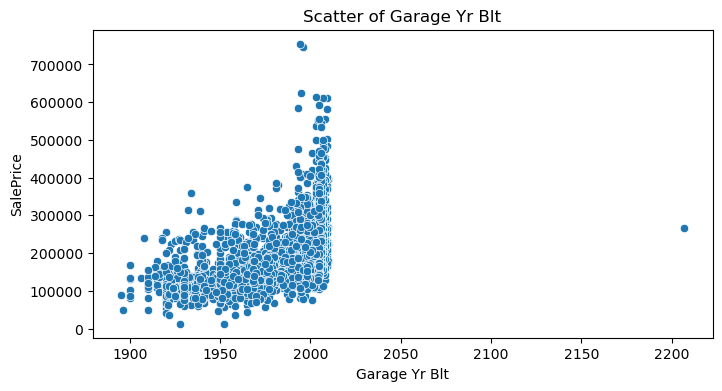

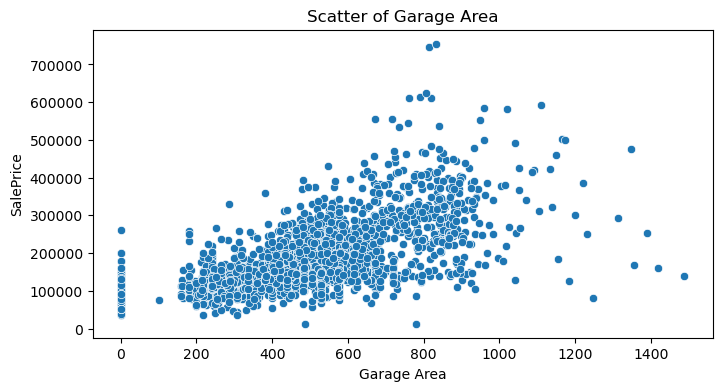

In [17]:
features = [
    'Mas Vnr Area',
    'Total Bsmt SF',
    '1st Flr SF',
    'Gr Liv Area',
    'Garage Yr Blt',
    'Garage Area'
]

for feature in features:
    plt.figure(figsize=(8,4))
    sns.scatterplot(data=df, x=feature,y='SalePrice')
    plt.title(f'Scatter of {feature}')
    plt.show()

<Axes: xlabel='Full Bath', ylabel='SalePrice'>

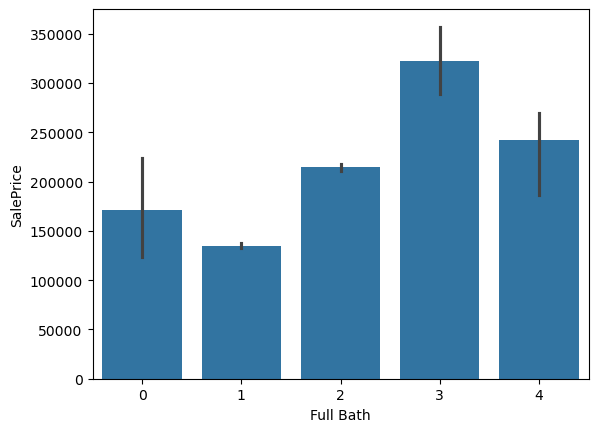

In [18]:
sns.barplot(x='Full Bath',y='SalePrice',data=df)

<Axes: xlabel='Garage Cars', ylabel='SalePrice'>

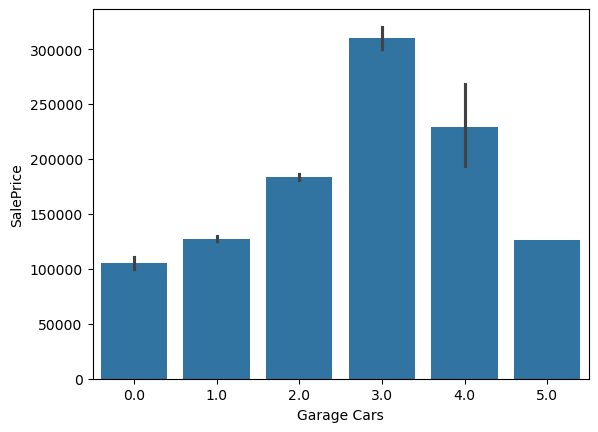

In [19]:
sns.barplot(x='Garage Cars',y='SalePrice',data=df)

In [20]:
cat_features = [
    'Sale Condition'
] 

<Axes: xlabel='Sale Condition', ylabel='count'>

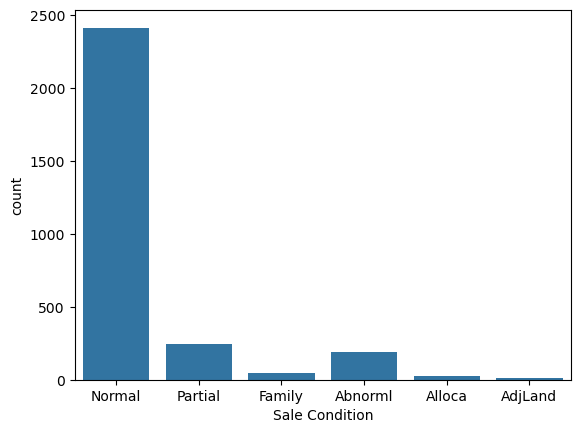

In [21]:
sns.countplot(x='Sale Condition',data=df)

<Axes: xlabel='Sale Condition', ylabel='SalePrice'>

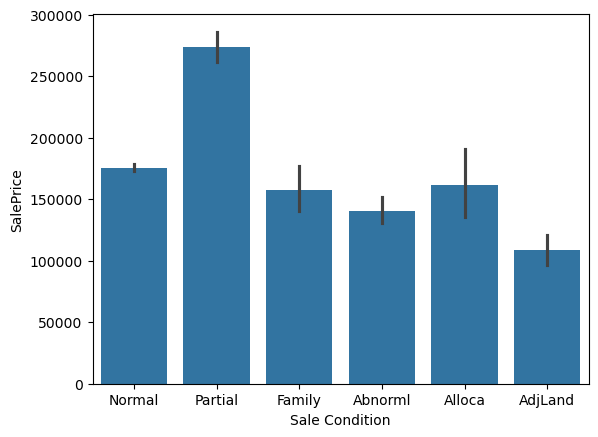

In [22]:
sns.barplot(x='Sale Condition',y='SalePrice',data=df)

In [23]:

df['House Style'].value_counts()

House Style
1Story    1481
2Story     873
1.5Fin     314
SLvl       128
SFoyer      83
2.5Unf      24
1.5Unf      19
2.5Fin       8
Name: count, dtype: int64

In [24]:


df['Foundation'].value_counts()


Foundation
PConc     1310
CBlock    1244
BrkTil     311
Slab        49
Stone       11
Wood         5
Name: count, dtype: int64

In [25]:
df['Neighborhood'].value_counts()

Neighborhood
NAmes      443
CollgCr    267
OldTown    239
Edwards    194
Somerst    182
NridgHt    166
Gilbert    165
Sawyer     151
NWAmes     131
SawyerW    125
Mitchel    114
BrkSide    108
Crawfor    103
IDOTRR      93
Timber      72
NoRidge     71
StoneBr     51
SWISU       48
ClearCr     44
MeadowV     37
BrDale      30
Blmngtn     28
Veenker     24
NPkVill     23
Blueste     10
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64

<Axes: xlabel='House Style', ylabel='SalePrice'>

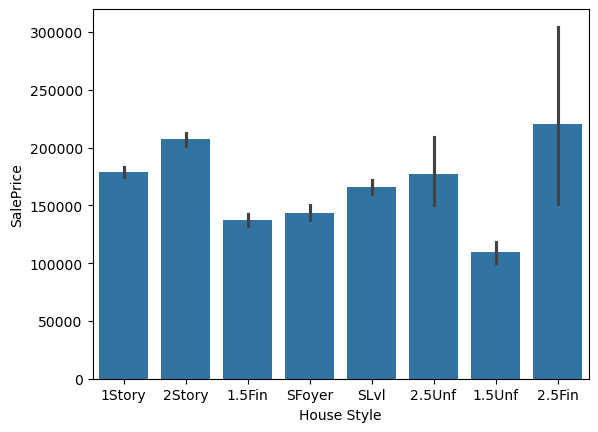

In [26]:
sns.barplot(x='House Style',y='SalePrice',data=df)

<Axes: xlabel='Foundation', ylabel='SalePrice'>

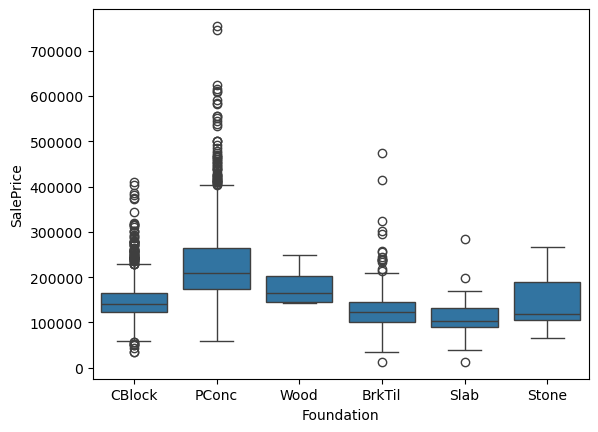

In [27]:
sns.boxplot(x='Foundation', y='SalePrice', data=df)

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

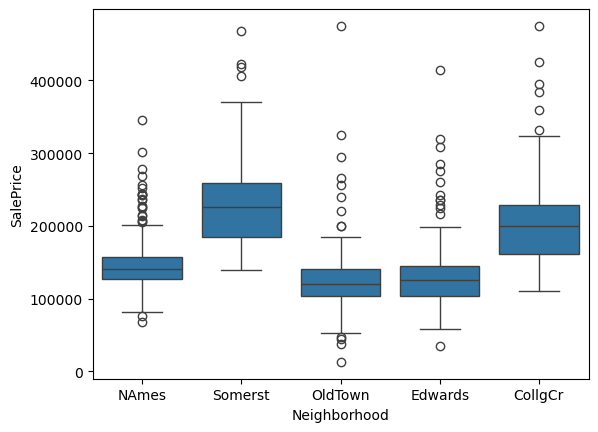

In [28]:
top_neighborhoods = df['Neighborhood'].value_counts().head(5).index

sns.boxplot(
    data=df[df['Neighborhood'].isin(top_neighborhoods)],
    x='Neighborhood',
    y='SalePrice'
)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 80 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MS SubClass      2930 non-null   int64  
 1   MS Zoning        2930 non-null   object 
 2   Lot Frontage     2440 non-null   float64
 3   Lot Area         2930 non-null   int64  
 4   Street           2930 non-null   object 
 5   Alley            198 non-null    object 
 6   Lot Shape        2930 non-null   object 
 7   Land Contour     2930 non-null   object 
 8   Utilities        2930 non-null   object 
 9   Lot Config       2930 non-null   object 
 10  Land Slope       2930 non-null   object 
 11  Neighborhood     2930 non-null   object 
 12  Condition 1      2930 non-null   object 
 13  Condition 2      2930 non-null   object 
 14  Bldg Type        2930 non-null   object 
 15  House Style      2930 non-null   object 
 16  Overall Qual     2930 non-null   int64  
 17  Overall Cond  

In [31]:
df.to_csv("cleaned_dataset.csv", index=False)